<a href="https://colab.research.google.com/github/Krishal555/AI-and-Machine-Learning/blob/master/2408955_Krishal_Maharjan_Code_Image_Classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Skin Cancer Predicton
Krishal Maharjan - 2408955

## Dataset Analysis

### 1. What does the dataset represent? Provide a brief description.
This dataset is used for **Skin Cancer Classification**. It contains images of various skin lesions, categorized into different types of skin conditions, likely for training a convolutional neural network (CNN) to distinguish between them.

### 2. How many total images are in the dataset?
There are **2176** total images in the dataset, located in the `TRAIN_DIR`.

### 3. What is the distribution of images across different classes?
The distribution of images across the 9 classes (lesion types) is as follows:
- actinic keratosis: 107
- basal cell carcinoma: 369
- dermatofibroma: 88
- melanoma: 431
- nevus: 350
- pigmented benign keratosis: 455
- seborrheic keratosis: 70
- squamous cell carcinoma: 174
- vascular lesion: 132

This distribution was visualized in the notebook using a bar plot, showing an imbalance across classes.

### 4. How is the dataset split into training and validation sets? Justify your choice.
Initially, the dataset was split into training and validation sets using an 80/20 ratio (`validation_split=0.2`). For the baseline model, `ImageDataGenerator` created 1744 training images and 432 validation images. For the deeper and transfer learning models, a `tf.data.Dataset` pipeline was used, which performed a stratified `train_test_split` on image paths and labels with `test_size=0.2` and `random_state=42`, resulting in 1740 training samples and 436 validation samples. The training set was then oversampled to balance class distribution, while the validation set remained unsampled. This stratified split ensures that each class is proportionally represented in both the training and validation sets, which is crucial for imbalanced datasets to prevent the model from performing poorly on minority classes. The 80/20 ratio is a commonly accepted split for machine learning tasks.

### 5. What preprocessing techniques (e.g., resizing, normalization) were applied?
The following preprocessing techniques were applied:
- **Resizing**: Images were resized to `(180, 180)` for the baseline and deeper models, and to `(224, 224)` for the EfficientNetB3 transfer learning model (`TL_IMG_SIZE`).
- **Normalization/Rescaling**: Image pixel values were rescaled from `[0, 255]` to `[0, 1]` by dividing by 255 (`rescale=1./255` or `img / 255.0`). For the EfficientNetB3 model, a specific `efficientnet_preprocess_input` function was applied.

### 6. What data generators, if any, were used for preprocessing and augmentation?
- Initially, `ImageDataGenerator` from `tensorflow.keras.preprocessing.image` was used for both preprocessing (rescaling) and augmentation (rotation, shifts, zoom, flips, brightness, channel shift) for the baseline model setup.
- For the deeper and transfer learning models, a custom `tf.data.Dataset` pipeline was implemented. This pipeline included a conditional augmentation function (`apply_conditional_augmentation`) that used `tf.keras.Sequential` layers like `layers.RandomFlip`, `layers.RandomRotation`, `layers.RandomZoom`, `layers.RandomContrast`, `layers.RandomTranslation`, and `layers.RandomBrightness`. This conditional augmentation applied aggressive augmentation to minority classes and standard augmentation to majority classes.
- RandomOverSampler from `imblearn.over_sampling` was used to balance the class distribution of the metadata (image paths and labels) before creating the `tf.data.Dataset` for training.



In [ ]:
import os
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight

# Set seeds for reproducibility
tf.random.set_seed(42)
np.random.seed(42)

# Configuration
IMG_SIZE = (180, 180)
BATCH_SIZE = 32
TRAIN_DIR = '/content/drive/MyDrive/AI & ML Coursework Assessment/Skin Cancer Classification-20260506T084251Z-3-001/Skin Cancer Classification/Train'
TEST_DIR = '/content/drive/MyDrive/AI & ML Coursework Assessment/Skin Cancer Classification-20260506T084251Z-3-001/Skin Cancer Classification/Test'

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import shutil
from PIL.Image import UnidentifiedImageError # Import the specific error

# Define a directory for corrupted images
CORRUPTED_DIR = '/content/drive/MyDrive/AI & ML Coursework Assessment/Skin Cancer Classification-20260506T084251Z-3-001/Skin Cancer Classification/Corrupted_Images'
os.makedirs(CORRUPTED_DIR, exist_ok=True)

def quarantine_corrupted_images(source_dir, dest_dir):
    corrupted_count = 0
    print(f"Scanning '{source_dir}' for corrupted images...")
    for class_name in os.listdir(source_dir):
        class_path = os.path.join(source_dir, class_name)
        if not os.path.isdir(class_path):
            continue

        dest_class_path = os.path.join(dest_dir, class_name)
        os.makedirs(dest_class_path, exist_ok=True)

        for img_name in os.listdir(class_path):
            img_path = os.path.join(class_path, img_name)
            try:
                # Attempt to load the image to check for corruption
                _ = tf.keras.preprocessing.image.load_img(img_path, target_size=IMG_SIZE)
            except Exception as e:
                # Check for UnidentifiedImageError from PIL or a string match
                if isinstance(e, UnidentifiedImageError) or "cannot identify image file" in str(e):
                    print(f"  Moving corrupted image: {img_path}")
                    shutil.move(img_path, dest_class_path)
                    corrupted_count += 1
                else:
                    print(f"  Skipping non-image file or other error: {img_path} - {e}")
    print(f"Finished scan. Total corrupted images moved: {corrupted_count}")

# Run the quarantine process
quarantine_corrupted_images(TRAIN_DIR, CORRUPTED_DIR)


Scanning '/content/drive/MyDrive/Skin Cancer Classification/Train' for corrupted images...
Finished scan. Total corrupted images moved: 0


/tmp/ipykernel_66170/2839193160.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=list(class_counts.keys()), y=list(class_counts.values()), palette='viridis')


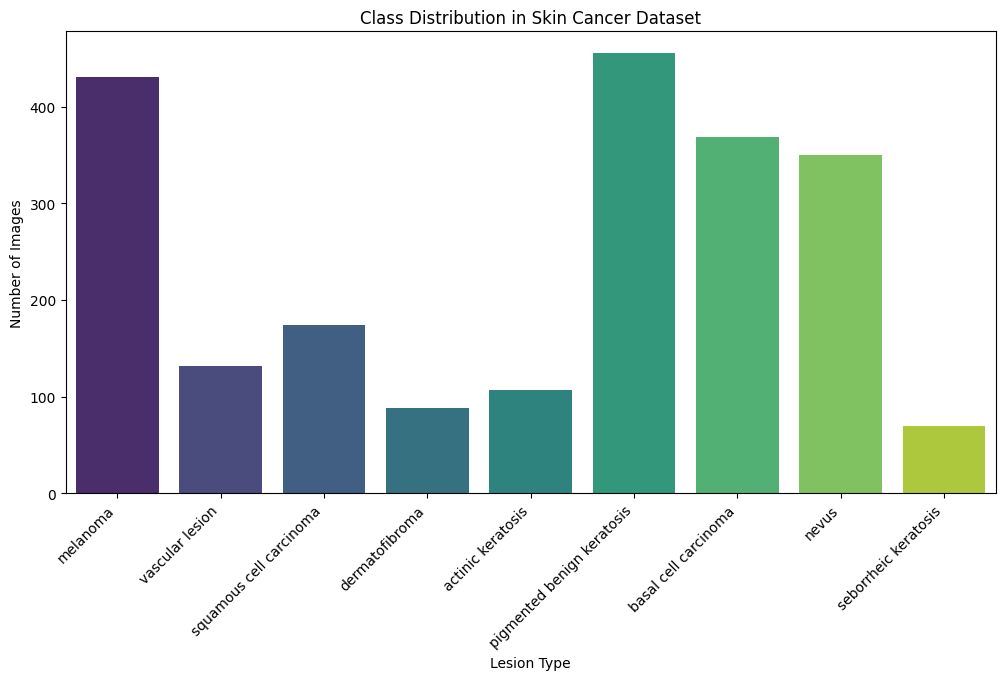

Total Images Found: 2176


In [ ]:
# 3. Count total images and display class distribution
class_counts = {}
for class_name in os.listdir(TRAIN_DIR):
    class_path = os.path.join(TRAIN_DIR, class_name)
    if os.path.isdir(class_path):
        counts = len(os.listdir(class_path))
        class_counts[class_name] = counts

# Visualize Distribution
plt.figure(figsize=(12, 6))
sns.barplot(x=list(class_counts.keys()), y=list(class_counts.values()), palette='viridis')
plt.xticks(rotation=45, ha='right')
plt.title('Class Distribution in Skin Cancer Dataset')
plt.xlabel('Lesion Type')
plt.ylabel('Number of Images')
plt.show()

print(f"Total Images Found: {sum(class_counts.values())}")

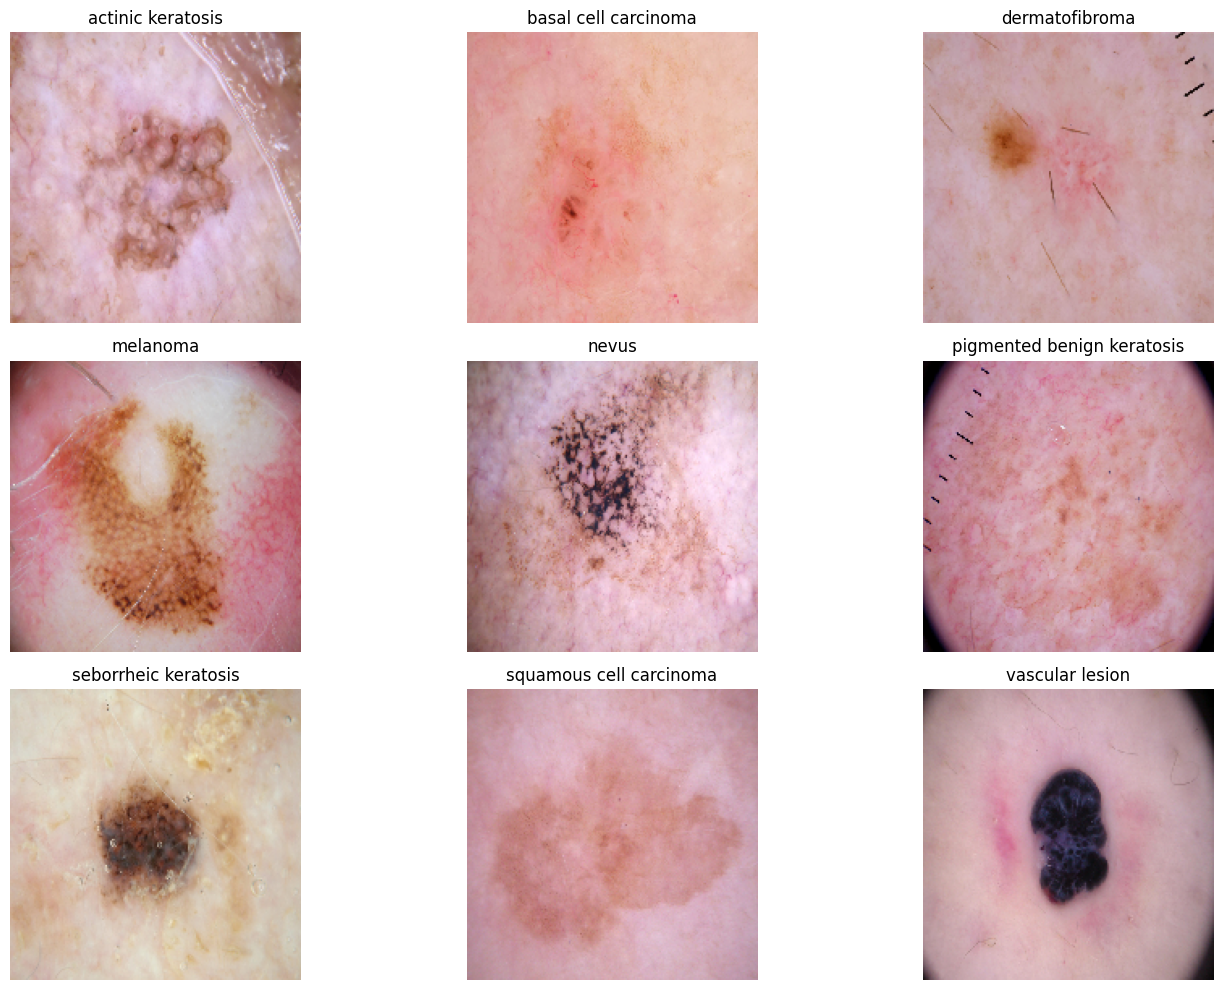

In [ ]:
plt.figure(figsize=(15, 10))
classes = sorted(list(class_counts.keys()))

for i, class_name in enumerate(classes):
    class_path = os.path.join(TRAIN_DIR, class_name)
    img_name = os.listdir(class_path)[0]
    img_path = os.path.join(class_path, img_name)

    img = tf.keras.preprocessing.image.load_img(img_path, target_size=IMG_SIZE)
    plt.subplot(3, 3, i + 1)
    plt.imshow(img)
    plt.title(class_name)
    plt.axis('off')

plt.tight_layout()
plt.show()

In [ ]:
train_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2, # 80/20 split
    rotation_range=180,
    width_shift_range=0.15,
    height_shift_range=0.15,
    zoom_range=0.2,
    horizontal_flip=True,
    vertical_flip=True,
    brightness_range=[0.8, 1.2],
    channel_shift_range=20,
    fill_mode='nearest'
)

val_datagen = ImageDataGenerator(rescale=1./255, validation_split=0.2)

train_generator = train_datagen.flow_from_directory(
    TRAIN_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='training',
    seed=42
)

val_generator = val_datagen.flow_from_directory(
    TRAIN_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='validation',
    seed=42,
    shuffle=False
)

print(f"Class Indices: {train_generator.class_indices}")

Found 1744 images belonging to 9 classes.
Found 432 images belonging to 9 classes.
Class Indices: {'actinic keratosis': 0, 'basal cell carcinoma': 1, 'dermatofibroma': 2, 'melanoma': 3, 'nevus': 4, 'pigmented benign keratosis': 5, 'seborrheic keratosis': 6, 'squamous cell carcinoma': 7, 'vascular lesion': 8}


In [ ]:
labels = train_generator.classes
class_labels = np.unique(labels)
weights = compute_class_weight(class_weight='balanced', classes=class_labels, y=labels)
class_weight_dict = dict(zip(class_labels, weights))

print("Calculated Class Weights:")
for idx, weight in class_weight_dict.items():
    print(f"Class {idx} ({classes[idx]}): {weight:.4f}")

Calculated Class Weights:
Class 0 (actinic keratosis): 2.2532
Class 1 (basal cell carcinoma): 0.6547
Class 2 (dermatofibroma): 2.7293
Class 3 (melanoma): 0.5617
Class 4 (nevus): 0.6921
Class 5 (pigmented benign keratosis): 0.5324
Class 6 (seborrheic keratosis): 3.4603
Class 7 (squamous cell carcinoma): 1.3841
Class 8 (vascular lesion): 1.8281


In [ ]:
import tensorflow as tf
from tensorflow.keras import layers

# Define minority classes based on counts
# We define a threshold to consider a class as 'minority'
MINORITY_THRESHOLD = 175 # Based on observation of class_counts: 70, 88, 107, 132, 174 are below this.

minority_class_names = [name for name, count in class_counts.items() if count < MINORITY_THRESHOLD]
minority_class_indices = [idx for idx, name in enumerate(classes) if name in minority_class_names]

print(f"Minority classes (count < {MINORITY_THRESHOLD}):")
for idx, name in enumerate(classes):
    if idx in minority_class_indices:
        print(f"  - {name} (Index: {idx}, Count: {class_counts[name]})")

# Define a standard augmenter (for majority classes) and an aggressive augmenter (for minority classes)
# These will be applied within the tf.data.Dataset pipeline.
standard_augmenter = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.2),
    layers.RandomContrast(0.2),
])

aggressive_augmenter = tf.keras.Sequential([
    layers.RandomFlip("horizontal_and_vertical"),
    layers.RandomRotation(0.3),
    layers.RandomZoom(0.3, 0.3),
    layers.RandomTranslation(0.1, 0.1),
    layers.RandomContrast(0.4),
    layers.RandomBrightness(0.2),
])


Minority classes (count < 175):
  - actinic keratosis (Index: 0, Count: 107)
  - dermatofibroma (Index: 2, Count: 88)
  - seborrheic keratosis (Index: 6, Count: 70)
  - squamous cell carcinoma (Index: 7, Count: 174)
  - vascular lesion (Index: 8, Count: 132)


In [ ]:
import tensorflow as tf


train_ds_raw, val_ds_raw = tf.keras.utils.image_dataset_from_directory(
    TRAIN_DIR,
    validation_split=0.2,
    subset="both",
    seed=42,
    image_size=IMG_SIZE, # Use IMG_SIZE (180,180) for the deeper model
    batch_size=BATCH_SIZE,
    label_mode='int'
)

# Define the conditional augmentation function
@tf.function
def apply_conditional_augmentation(image_batch, label_batch):
    # Determine for each image in the batch if its label is a minority class
    is_minority_mask = tf.reduce_any(
        tf.equal(tf.expand_dims(label_batch, -1), tf.constant(minority_class_indices, dtype=tf.int32)),
        axis=1
    ) # This will be a boolean tensor of shape [BATCH_SIZE]

    # Apply standard augmentation to all images
    standard_augmented = standard_augmenter(image_batch, training=True)

    # Apply aggressive augmentation to all images
    aggressive_augmented = aggressive_augmenter(image_batch, training=True)


    # Expand mask to match image dimensions for broadcasting
    augmented_image_batch = tf.where(
        tf.reshape(is_minority_mask, [-1, 1, 1, 1]), # Reshape to (batch_size, 1, 1, 1) for broadcasting
        aggressive_augmented,
        standard_augmented
    )
    return augmented_image_batch, label_batch

# Convert integer labels to one-hot for training (after augmentation)
def convert_to_one_hot(image, label):
    return image, tf.one_hot(label, depth=len(classes))

# Apply conditional augmentation, then global rescaling, then one-hot encoding for the training dataset
train_ds_final = train_ds_raw.map(apply_conditional_augmentation, num_parallel_calls=tf.data.AUTOTUNE) \
                             .map(lambda img, label: (img / 255.0, label)) \
                             .map(convert_to_one_hot) \
                             .cache() \
                             .shuffle(1000) \
                             .prefetch(tf.data.AUTOTUNE)

# For validation, only apply rescaling and one-hot encoding (no augmentation)
val_ds_final = val_ds_raw.map(lambda img, label: (img / 255.0, label)) \
                           .map(convert_to_one_hot) \
                           .cache() \
                           .prefetch(tf.data.AUTOTUNE)

print("Targeted data augmentation pipeline created for deeper models.")

Found 2176 files belonging to 9 classes.
Using 1741 files for training.
Using 435 files for validation.
Targeted data augmentation pipeline created for deeper models.


In [ ]:
import numpy as np
from imblearn.over_sampling import RandomOverSampler

# 1. Get all image paths and their corresponding labels
image_paths = []
labels = []
label_to_int = train_generator.class_indices

for class_name_str, class_idx in label_to_int.items():
    class_path = os.path.join(TRAIN_DIR, class_name_str)
    if os.path.isdir(class_path):
        for img_name in os.listdir(class_path):
            img_path = os.path.join(class_path, img_name)
            try:
                _ = tf.keras.preprocessing.image.load_img(img_path, target_size=IMG_SIZE)
                image_paths.append(img_path)
                labels.append(class_idx)
            except Exception:
                pass

image_paths = np.array(image_paths)
labels = np.array(labels, dtype=np.int32) # Explicitly cast to int32

print(f"Original dataset size: {len(image_paths)}")
unique_labels_original, counts_original = np.unique(labels, return_counts=True)
print("Original class distribution (before explicit oversampling):")
for label_idx, count in zip(unique_labels_original, counts_original):
    print(f"  Class {classes[label_idx]} ({label_idx}): {count} samples")

# 2. Apply Random Oversampling to metadata
ros = RandomOverSampler(random_state=42)
# Reshape image_paths to 2D for the sampler, as it expects X to be 2D
image_paths_resampled, labels_resampled = ros.fit_resample(image_paths.reshape(-1, 1), labels)

# Convert back to 1D arrays
image_paths_resampled = image_paths_resampled.flatten()
labels_resampled = labels_resampled.astype(np.int32) # Ensure resampled labels are int32

print(f"\nOversampled dataset size: {len(image_paths_resampled)}")
unique_labels_resampled, counts_resampled = np.unique(labels_resampled, return_counts=True)
print("Oversampled class distribution (after explicit oversampling):")
for label_idx, count in zip(unique_labels_resampled, counts_resampled):
    print(f"  Class {classes[label_idx]} ({label_idx}): {count} samples")

# 3. Create a new tf.data.Dataset from oversampled data
# Helper function to load and decode image from path
def load_image_and_label_from_path(image_path_tensor, label_tensor):
    image_path = image_path_tensor.numpy().decode('utf-8')
    image = tf.io.read_file(image_path)
    image = tf.image.decode_jpeg(image, channels=3)
    image = tf.image.resize(image, IMG_SIZE)
    # Ensure label is int32 here as well, although it should already be from the numpy array
    return image, tf.cast(label_tensor, tf.int32)

# Create dataset from oversampled paths and labels
oversampled_ds_raw = tf.data.Dataset.from_tensor_slices((image_paths_resampled, labels_resampled))

# Map the loading function using tf.py_function
oversampled_ds_processed = oversampled_ds_raw.map(
    lambda x, y: tf.py_function(
        load_image_and_label_from_path, [x, y], [tf.float32, tf.int32]
    ),
    num_parallel_calls=tf.data.AUTOTUNE
)

# Explicitly set the shape of the tensors, as tf.py_function might return tensors with unknown shapes
oversampled_ds_processed = oversampled_ds_processed.map(
    lambda image, label: (tf.ensure_shape(image, [IMG_SIZE[0], IMG_SIZE[1], 3]), tf.ensure_shape(label, []))
)

# Apply existing augmentation and preprocessing pipeline
# Ensure batching happens *before* apply_conditional_augmentation
train_ds_oversampled_final = oversampled_ds_processed.cache() \
                                            .shuffle(1000) \
                                            .batch(BATCH_SIZE) \
                                            .map(apply_conditional_augmentation, num_parallel_calls=tf.data.AUTOTUNE) \
                                            .map(lambda img, label: (img / 255.0, label)) \
                                            .map(convert_to_one_hot) \
                                            .prefetch(tf.data.AUTOTUNE)

print("\nNew oversampled tf.data.Dataset 'train_ds_oversampled_final' created.")


Original dataset size: 2176
Original class distribution (before explicit oversampling):
  Class actinic keratosis (0): 107 samples
  Class basal cell carcinoma (1): 369 samples
  Class dermatofibroma (2): 88 samples
  Class melanoma (3): 431 samples
  Class nevus (4): 350 samples
  Class pigmented benign keratosis (5): 455 samples
  Class seborrheic keratosis (6): 70 samples
  Class squamous cell carcinoma (7): 174 samples
  Class vascular lesion (8): 132 samples

Oversampled dataset size: 4095
Oversampled class distribution (after explicit oversampling):
  Class actinic keratosis (0): 455 samples
  Class basal cell carcinoma (1): 455 samples
  Class dermatofibroma (2): 455 samples
  Class melanoma (3): 455 samples
  Class nevus (4): 455 samples
  Class pigmented benign keratosis (5): 455 samples
  Class seborrheic keratosis (6): 455 samples
  Class squamous cell carcinoma (7): 455 samples
  Class vascular lesion (8): 455 samples

New oversampled tf.data.Dataset 'train_ds_oversampled_f

In [ ]:
from tensorflow.keras import layers, models, optimizers, callbacks
from sklearn.metrics import classification_report, confusion_matrix

# Baseline CNN Architecture
def build_baseline_model():
    model = models.Sequential([
        # Input layer
        layers.Input(shape=(180, 180, 3)),

        # First Conv Block
        layers.Conv2D(32, (3, 3), activation='relu'),
        layers.MaxPooling2D((2, 2)),

        # Second Conv Block
        layers.Conv2D(64, (3, 3), activation='relu'),
        layers.MaxPooling2D((2, 2)),

        # Third Conv Block
        layers.Conv2D(128, (3, 3), activation='relu'),
        layers.MaxPooling2D((2, 2)),

        # Classification Head
        layers.Flatten(),
        layers.Dense(256, activation='relu'),
        layers.Dense(128, activation='relu'),
        layers.Dense(64, activation='relu'),
        layers.Dense(9, activation='softmax')
    ])
    return model

baseline_model = build_baseline_model()
baseline_model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 178, 178, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 89, 89, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 87, 87, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 43, 43, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 41, 41, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 20, 20, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 51200)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │    13,107,456 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 9)              │           585 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 13,242,441 (50.52 MB)

 Trainable params: 13,242,441 (50.52 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
import tensorflow as tf
from tensorflow.keras import optimizers, callbacks

# Training configuration
optimizer = optimizers.Adam(learning_rate=5e-4)
baseline_model.compile(optimizer=optimizer, loss='categorical_crossentropy', metrics=['accuracy'])

# Callbacks
base_callbacks = [
    callbacks.EarlyStopping(monitor='val_loss', patience=7, restore_best_weights=True),
    callbacks.ModelCheckpoint('baseline_best.keras', monitor='val_accuracy', save_best_only=True),
    callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.3, patience=4)
]

# Train Baseline Model using the new tf.data.Dataset pipeline
start_time = time.time()
history_baseline = baseline_model.fit(
    train_ds_oversampled_final,
    validation_data=val_ds_final,
    epochs=50,
    callbacks=base_callbacks
)
end_time = time.time()

print(f"Total Training Time for Baseline: {end_time - start_time:.2f} seconds")

Epoch 1/50
128/128 ━━━━━━━━━━━━━━━━━━━━ 76s 530ms/step - accuracy: 0.4425 - loss: 1.5520 - val_accuracy: 0.2782 - val_loss: 1.9042 - learning_rate: 5.0000e-04
Epoch 2/50
128/128 ━━━━━━━━━━━━━━━━━━━━ 66s 508ms/step - accuracy: 0.4462 - loss: 1.5160 - val_accuracy: 0.2460 - val_loss: 2.0675 - learning_rate: 5.0000e-04
Epoch 3/50
128/128 ━━━━━━━━━━━━━━━━━━━━ 84s 524ms/step - accuracy: 0.4410 - loss: 1.4898 - val_accuracy: 0.2644 - val_loss: 1.8551 - learning_rate: 5.0000e-04
Epoch 4/50
128/128 ━━━━━━━━━━━━━━━━━━━━ 66s 506ms/step - accuracy: 0.4462 - loss: 1.4563 - val_accuracy: 0.2966 - val_loss: 1.8594 - learning_rate: 5.0000e-04
Epoch 5/50
128/128 ━━━━━━━━━━━━━━━━━━━━ 68s 528ms/step - accuracy: 0.4217 - loss: 1.4606 - val_accuracy: 0.3218 - val_loss: 1.7433 - learning_rate: 5.0000e-04
Epoch 6/50
128/128 ━━━━━━━━━━━━━━━━━━━━ 66s 505ms/step - accuracy: 0.4352 - loss: 1.4166 - val_accuracy: 0.2989 - val_loss: 1.7858 - learning_rate: 5.0000e-04
Epoch 7/50
128/128 ━━━━━━━━━━━━━━━━━━━━ 67s 51

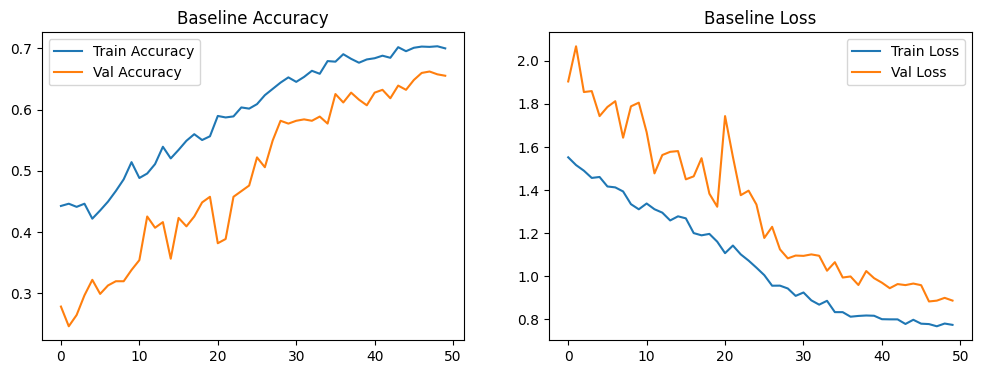

In [ ]:
import matplotlib.pyplot as plt

# Evaluation Metrics

# 1. Accuracy and Loss Curves
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history_baseline.history['accuracy'], label='Train Accuracy')
plt.plot(history_baseline.history['val_accuracy'], label='Val Accuracy')
plt.title('Baseline Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history_baseline.history['loss'], label='Train Loss')
plt.plot(history_baseline.history['val_loss'], label='Val Loss')
plt.title('Baseline Loss')
plt.legend()
plt.show()

14/14 ━━━━━━━━━━━━━━━━━━━━ 1s 41ms/step
Classification Report:
                            precision    recall  f1-score   support

         actinic keratosis       0.37      0.59      0.45        17
      basal cell carcinoma       0.72      0.64      0.68        69
            dermatofibroma       0.37      0.62      0.47        16
                  melanoma       0.69      0.58      0.63        81
                     nevus       0.71      0.65      0.68        72
pigmented benign keratosis       0.81      0.76      0.78        95
      seborrheic keratosis       0.23      0.43      0.30        14
   squamous cell carcinoma       0.47      0.49      0.48        37
           vascular lesion       1.00      0.97      0.99        34

                  accuracy                           0.66       435
                 macro avg       0.60      0.64      0.61       435
              weighted avg       0.69      0.66      0.67       435



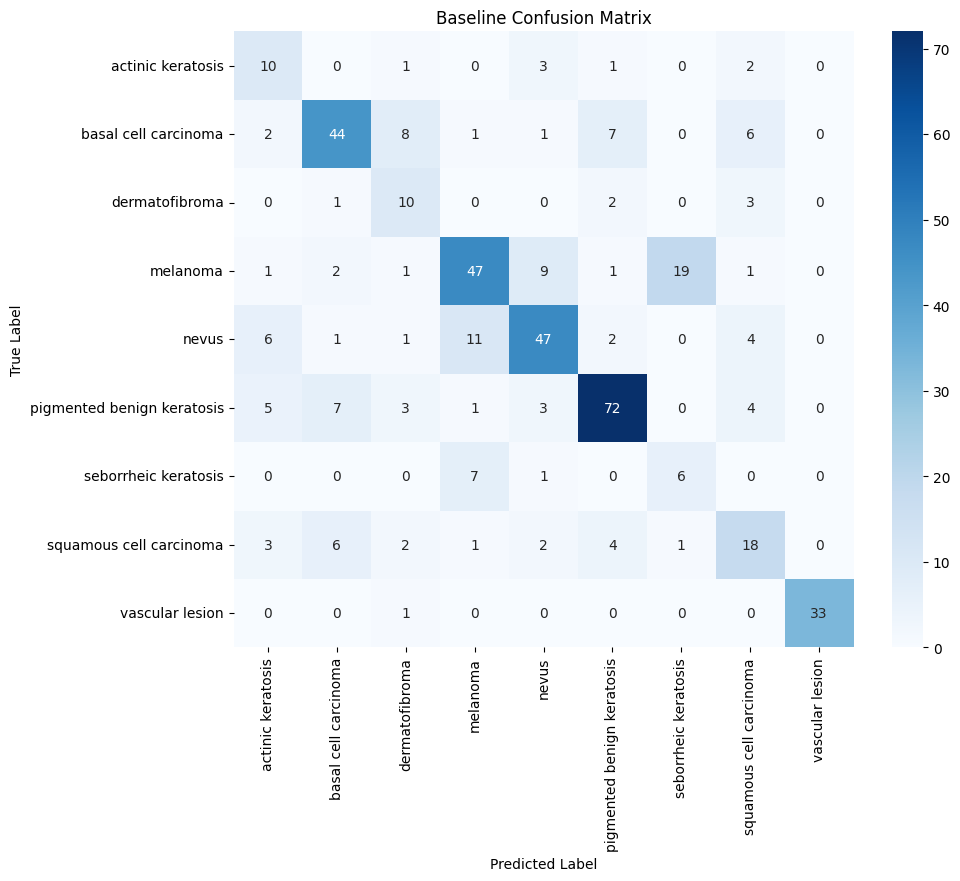

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix

# 2. Detailed Classification Metrics

# Get true labels from val_ds_final
y_true = np.concatenate([y.numpy() for x, y in val_ds_final], axis=0)
y_true = np.argmax(y_true, axis=1)

# Make predictions on the validation set
Y_pred = baseline_model.predict(val_ds_final)
y_pred = np.argmax(Y_pred, axis=1)

print("Classification Report:")
print(classification_report(y_true, y_pred, target_names=classes))

# 3. Confusion Matrix
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=classes, yticklabels=classes, cmap='Blues')
plt.title('Baseline Confusion Matrix')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()

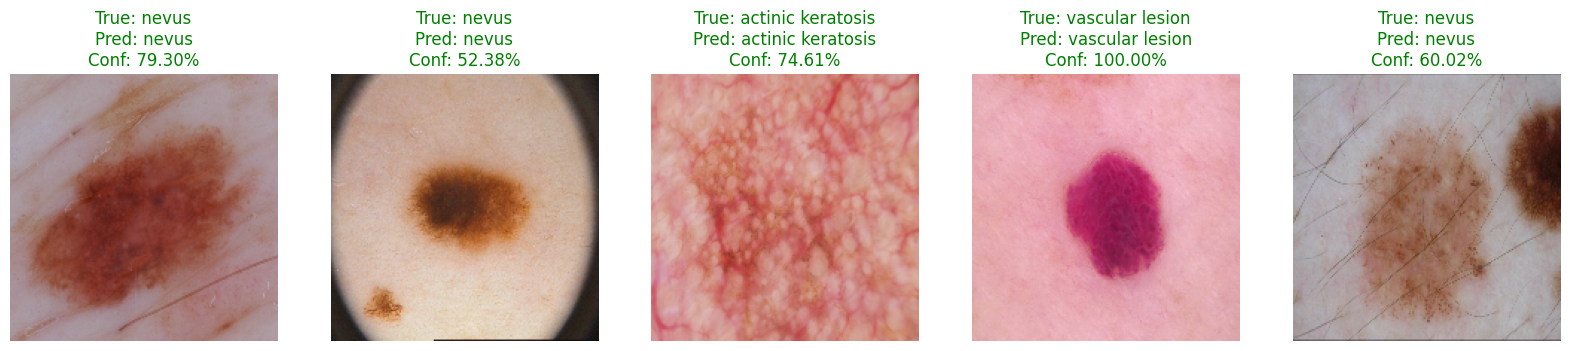

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# 4. Inference on random samples
def predict_random_samples(model, dataset, num_samples=5):
    # Get random samples from the dataset
    sample_images = []
    sample_labels = []
    for images, labels in dataset.unbatch().take(num_samples):
        sample_images.append(images.numpy())
        sample_labels.append(np.argmax(labels.numpy())) # Convert one-hot to int

    plt.figure(figsize=(20, 4))
    for i, (img_array, true_label_idx) in enumerate(zip(sample_images, sample_labels)):
        img_batch = np.expand_dims(img_array, axis=0)

        # Predict
        prediction = model.predict(img_batch, verbose=0)
        pred_idx = np.argmax(prediction[0])
        confidence = prediction[0][pred_idx] * 100
        pred_label = classes[pred_idx]
        true_label = classes[true_label_idx]

        plt.subplot(1, num_samples, i + 1)
        plt.imshow(img_array)
        color = 'green' if pred_label == true_label else 'red'
        plt.title(f"True: {true_label}\nPred: {pred_label}\nConf: {confidence:.2f}%", color=color)
        plt.axis('off')
    plt.show()

predict_random_samples(baseline_model, val_ds_final)

### 2.5.3 Deeper Architecture with Regularization Layers

We will now construct a deeper CNN model by increasing the number of convolutional and dense layers, and introduce several regularization techniques to improve generalization and aim for higher accuracy.

In [ ]:
from tensorflow.keras import layers, models, optimizers, callbacks, regularizers

# Deeper CNN Architecture with Regularization
def build_deeper_model(img_size=(IMG_SIZE[0], IMG_SIZE[1])):
    model = models.Sequential([
        # Input layer
        layers.Input(shape=(img_size[0], img_size[1], 3)),

        # First Conv Block (Baseline: 32 filters)
        layers.Conv2D(32, (3, 3), activation='relu'),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2, 2)),

        # Second Conv Block (Baseline: 64 filters)
        layers.Conv2D(64, (3, 3), activation='relu'),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2, 2)),

        # Third Conv Block (Baseline: 128 filters)
        layers.Conv2D(128, (3, 3), activation='relu'),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2, 2)),

        # Fourth Conv Block (New, deeper)
        layers.Conv2D(256, (3, 3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2, 2)),
        layers.Dropout(0.25),

        # Fifth Conv Block (New, deeper)
        layers.Conv2D(512, (3, 3), activation='relu'),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2, 2)),
        layers.Dropout(0.3),

        # Classification Head
        layers.Flatten(),

        # Dense Layer 1 (larger, with BN and Dropout)
        layers.Dense(512, activation='relu', kernel_regularizer=regularizers.l2(1e-4)),
        layers.BatchNormalization(),
        layers.Dropout(0.5),

        # Dense Layer 2 (with BN and Dropout)
        layers.Dense(256, activation='relu', kernel_regularizer=regularizers.l2(1e-4)),
        layers.BatchNormalization(),
        layers.Dropout(0.5),

        # Dense Layer 3 (with BN and Dropout)
        layers.Dense(128, activation='relu', kernel_regularizer=regularizers.l2(1e-4)),
        layers.BatchNormalization(),
        layers.Dropout(0.5),

        # Output Layer
        layers.Dense(len(classes), activation='softmax') # Use `len(classes)` for dynamic output units
    ])
    return model

deep_model = build_deeper_model()
deep_model.summary()

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_15 (Conv2D)              │ (None, 178, 178, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_27          │ (None, 178, 178, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_15 (MaxPooling2D) │ (None, 89, 89, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_16 (Conv2D)              │ (None, 87, 87, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_28          │ (None, 87, 87, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_16 (MaxPooling2D) │ (None, 43, 43, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_17 (Conv2D)              │ (None, 41, 41, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_29          │ (None, 41, 41, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_17 (MaxPooling2D) │ (None, 20, 20, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_18 (Conv2D)              │ (None, 20, 20, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_30          │ (None, 20, 20, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_18 (MaxPooling2D) │ (None, 10, 10, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_19 (Dropout)            │ (None, 10, 10, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_19 (Conv2D)              │ (None, 8, 8, 512)      │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_31          │ (None, 8, 8, 512)      │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_19 (MaxPooling2D) │ (None, 4, 4, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_20 (Dropout)            │ (None, 4, 4, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 8192)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 512)            │     4,194,816 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_32          │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_21 (Dropout)            │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 256)            │       131,32

 Total params: 5,936,329 (22.65 MB)

 Trainable params: 5,932,553 (22.63 MB)

 Non-trainable params: 3,776 (14.75 KB)

### 2. Model Training for Deeper Model

In [ ]:
import time

# Compile the Deeper Model
deep_model.compile(optimizer=optimizers.Adam(learning_rate=1e-4),
                   loss='categorical_crossentropy',
                   metrics=['accuracy'])

# Callbacks for the deeper model
deep_callbacks = [
    callbacks.EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True),
    callbacks.ModelCheckpoint('deeper_best.keras', monitor='val_accuracy', save_best_only=True),
    callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.3, patience=5, min_lr=1e-6)
]

# Train the Deeper Model
print("\nTraining the Deeper Model...")
start_time_deep = time.time()
history_deep = deep_model.fit(
    train_ds_oversampled_final,
    validation_data=val_ds_final,
    epochs=40, # Potentially more epochs given deeper architecture and regularization
    callbacks=deep_callbacks
)
end_time_deep = time.time()

print(f"Total Training Time for Deeper Model: {end_time_deep - start_time_deep:.2f} seconds")


Training the Deeper Model...
Epoch 1/40
128/128 ━━━━━━━━━━━━━━━━━━━━ 115s 702ms/step - accuracy: 0.1690 - loss: 3.2024 - val_accuracy: 0.2184 - val_loss: 2.4306 - learning_rate: 1.0000e-04
Epoch 2/40
128/128 ━━━━━━━━━━━━━━━━━━━━ 75s 574ms/step - accuracy: 0.2002 - loss: 2.9350 - val_accuracy: 0.2552 - val_loss: 2.4775 - learning_rate: 1.0000e-04
Epoch 3/40
128/128 ━━━━━━━━━━━━━━━━━━━━ 78s 547ms/step - accuracy: 0.2295 - loss: 2.8121 - val_accuracy: 0.2414 - val_loss: 2.3552 - learning_rate: 1.0000e-04
Epoch 4/40
128/128 ━━━━━━━━━━━━━━━━━━━━ 83s 544ms/step - accuracy: 0.2361 - loss: 2.6888 - val_accuracy: 0.3011 - val_loss: 2.0318 - learning_rate: 1.0000e-04
Epoch 5/40
128/128 ━━━━━━━━━━━━━━━━━━━━ 82s 555ms/step - accuracy: 0.2694 - loss: 2.5525 - val_accuracy: 0.4000 - val_loss: 1.7842 - learning_rate: 1.0000e-04
Epoch 6/40
128/128 ━━━━━━━━━━━━━━━━━━━━ 87s 594ms/step - accuracy: 0.2874 - loss: 2.4380 - val_accuracy: 0.4161 - val_loss: 1.7168 - learning_rate: 1.0000e-04
Epoch 7/40
128/

14/14 ━━━━━━━━━━━━━━━━━━━━ 3s 171ms/step
Classification Report for Deeper Model:
                            precision    recall  f1-score   support

         actinic keratosis       0.21      0.24      0.22        17
      basal cell carcinoma       0.75      0.17      0.28        69
            dermatofibroma       0.04      0.06      0.05        16
                  melanoma       0.66      0.41      0.50        81
                     nevus       0.75      0.60      0.67        72
pigmented benign keratosis       0.44      0.94      0.60        95
      seborrheic keratosis       0.12      0.29      0.17        14
   squamous cell carcinoma       0.18      0.05      0.08        37
           vascular lesion       1.00      0.68      0.81        34

                  accuracy                           0.49       435
                 macro avg       0.46      0.38      0.38       435
              weighted avg       0.57      0.49      0.47       435



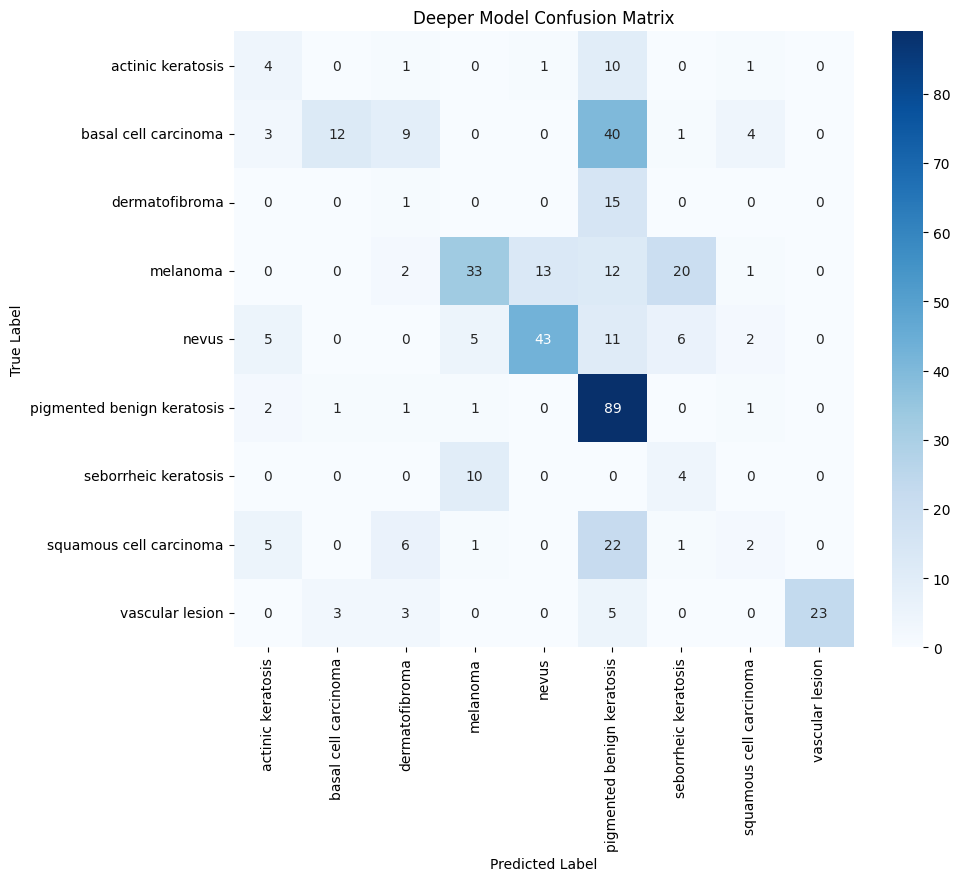

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix

# Get true labels from val_ds_final (assuming it's still available and correct)
y_true_deep = np.concatenate([y.numpy() for x, y in val_ds_final], axis=0)
y_true_deep = np.argmax(y_true_deep, axis=1)

# Make predictions on the validation set using the deep model
Y_pred_deep = deep_model.predict(val_ds_final)
y_pred_deep = np.argmax(Y_pred_deep, axis=1)

print("Classification Report for Deeper Model:")
print(classification_report(y_true_deep, y_pred_deep, target_names=classes))

# Confusion Matrix for Deeper Model
cm_deep = confusion_matrix(y_true_deep, y_pred_deep)
plt.figure(figsize=(10, 8))
sns.heatmap(cm_deep, annot=True, fmt='d', xticklabels=classes, yticklabels=classes, cmap='Blues')
plt.title('Deeper Model Confusion Matrix')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()

### 2.5.4 Experimentation and Comparative Analysis - Optimizer Analysis: SGD vs Adam

To compare the impact of different optimizers, we will now train the Deeper Model using the Stochastic Gradient Descent (SGD) optimizer. To ensure a fair comparison, we will re-initialize the `deep_model`'s architecture before compiling it with SGD.

In [ ]:
from tensorflow.keras import optimizers

# Rebuild the deeper model to get fresh weights for SGD training
deep_model_sgd = build_deeper_model(img_size=TL_IMG_SIZE)

# Compile the Deeper Model with SGD optimizer
sgd_optimizer = optimizers.SGD(learning_rate=1e-3, momentum=0.9)
deep_model_sgd.compile(optimizer=sgd_optimizer,
                       loss='categorical_crossentropy',
                       metrics=['accuracy'])

# Callbacks for the deeper model with SGD
sgd_callbacks = [
    callbacks.EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True),
    callbacks.ModelCheckpoint('deeper_sgd_best.keras', monitor='val_accuracy', save_best_only=True),
    callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.3, patience=5, min_lr=1e-6)
]

print("\nTraining the Deeper Model with SGD Optimizer...")
start_time_sgd = time.time()
history_deep_sgd = deep_model_sgd.fit(
    train_ds_tl_oversampled_final, # Using the TL dataset for consistency
    validation_data=val_ds_tl_final,
    epochs=40,
    callbacks=sgd_callbacks
)
end_time_sgd = time.time()

print(f"Total Training Time for Deeper Model (SGD): {end_time_sgd - start_time_sgd:.2f} seconds")


Training the Deeper Model with SGD Optimizer...
Epoch 1/40
103/103 ━━━━━━━━━━━━━━━━━━━━ 135s 1s/step - accuracy: 0.1810 - loss: 3.1809 - val_accuracy: 0.0940 - val_loss: 3.1810 - learning_rate: 0.0010
Epoch 2/40
103/103 ━━━━━━━━━━━━━━━━━━━━ 94s 901ms/step - accuracy: 0.2393 - loss: 2.5976 - val_accuracy: 0.1032 - val_loss: 3.3257 - learning_rate: 0.0010
Epoch 3/40
103/103 ━━━━━━━━━━━━━━━━━━━━ 90s 864ms/step - accuracy: 0.2750 - loss: 2.3578 - val_accuracy: 0.2936 - val_loss: 1.9300 - learning_rate: 0.0010
Epoch 4/40
103/103 ━━━━━━━━━━━━━━━━━━━━ 92s 872ms/step - accuracy: 0.3010 - loss: 2.1886 - val_accuracy: 0.3028 - val_loss: 2.1425 - learning_rate: 0.0010
Epoch 5/40
103/103 ━━━━━━━━━━━━━━━━━━━━ 143s 889ms/step - accuracy: 0.3031 - loss: 2.1085 - val_accuracy: 0.3028 - val_loss: 2.0198 - learning_rate: 0.0010
Epoch 6/40
103/103 ━━━━━━━━━━━━━━━━━━━━ 141s 887ms/step - accuracy: 0.3245 - loss: 2.0225 - val_accuracy: 0.2959 - val_loss: 1.9485 - learning_rate: 0.0010
Epoch 7/40
103/103 ━━

### Evaluate Deeper Model (SGD) Performance

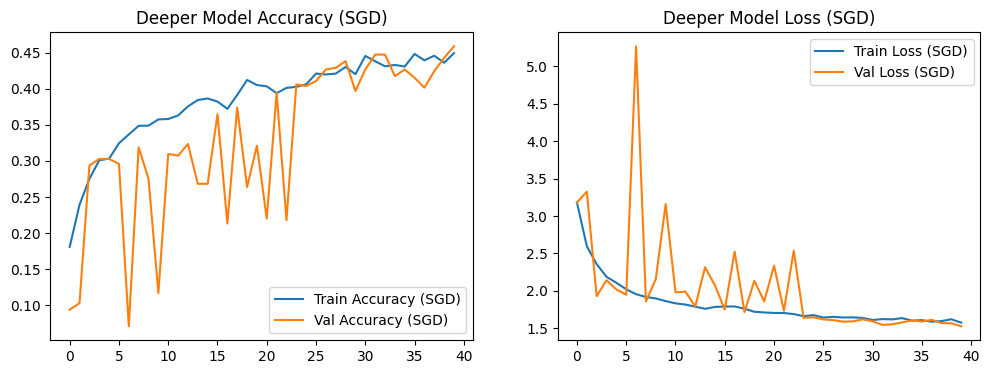

14/14 ━━━━━━━━━━━━━━━━━━━━ 2s 106ms/step
Classification Report for Deeper Model (SGD):
                            precision    recall  f1-score   support

         actinic keratosis       0.15      0.19      0.17        21
      basal cell carcinoma       0.52      0.58      0.55        74
            dermatofibroma       0.20      0.06      0.09        18
                  melanoma       0.59      0.12      0.19        86
                     nevus       0.65      0.50      0.56        70
pigmented benign keratosis       0.55      0.79      0.65        91
      seborrheic keratosis       0.16      0.79      0.27        14
   squamous cell carcinoma       0.31      0.31      0.31        35
           vascular lesion       0.93      0.48      0.63        27

                  accuracy                           0.46       436
                 macro avg       0.45      0.42      0.38       436
              weighted avg       0.53      0.46      0.44       436



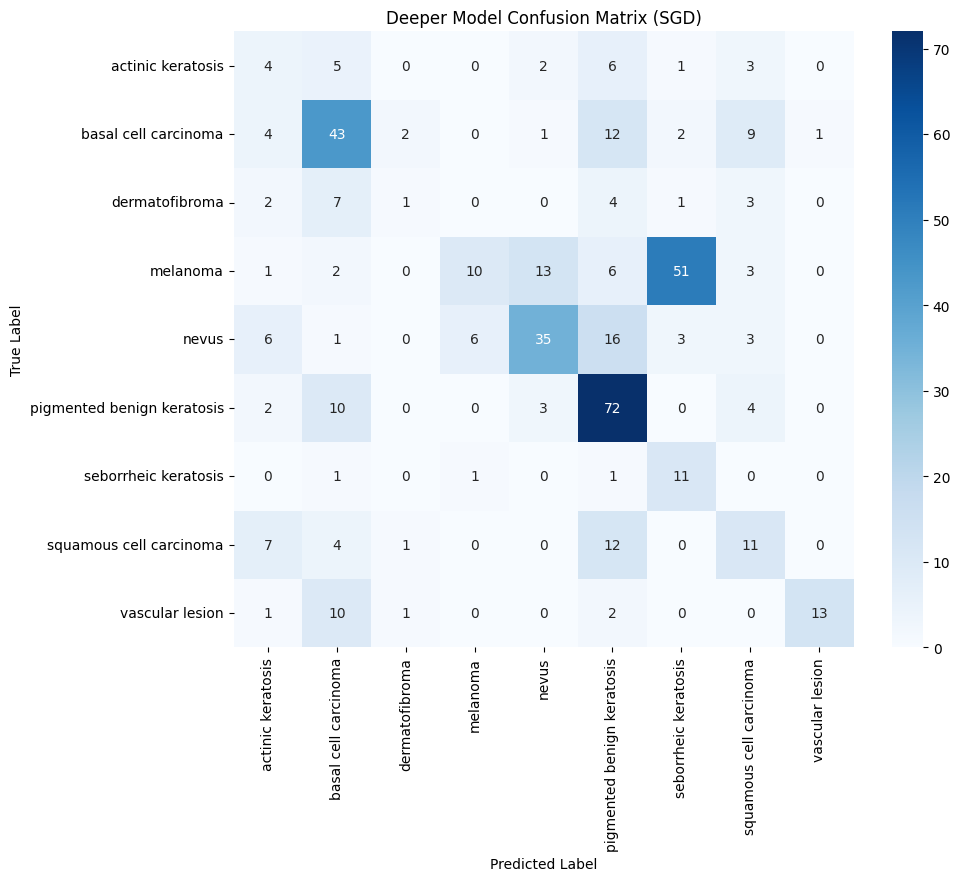

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix

# 1. Accuracy and Loss Curves for SGD model
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history_deep_sgd.history['accuracy'], label='Train Accuracy (SGD)')
plt.plot(history_deep_sgd.history['val_accuracy'], label='Val Accuracy (SGD)')
plt.title('Deeper Model Accuracy (SGD)')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history_deep_sgd.history['loss'], label='Train Loss (SGD)')
plt.plot(history_deep_sgd.history['val_loss'], label='Val Loss (SGD)')
plt.title('Deeper Model Loss (SGD)')
plt.legend()
plt.show()

# Get true labels from val_ds_tl_final
y_true_sgd = np.concatenate([y.numpy() for x, y in val_ds_tl_final], axis=0)
y_true_sgd = np.argmax(y_true_sgd, axis=1)

# Make predictions on the validation set using the SGD model
Y_pred_sgd = deep_model_sgd.predict(val_ds_tl_final)
y_pred_sgd = np.argmax(Y_pred_sgd, axis=1)

print("Classification Report for Deeper Model (SGD):")
print(classification_report(y_true_sgd, y_pred_sgd, target_names=classes))

# Confusion Matrix for Deeper Model (SGD)
cm_sgd = confusion_matrix(y_true_sgd, y_pred_sgd)
plt.figure(figsize=(10, 8))
sns.heatmap(cm_sgd, annot=True, fmt='d', xticklabels=classes, yticklabels=classes, cmap='Blues')
plt.title('Deeper Model Confusion Matrix (SGD)')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()


In [ ]:
from tensorflow.keras.applications import EfficientNetB3
from tensorflow.keras import layers, models, optimizers, callbacks, regularizers
# New input size for Transfer Learning
TL_IMG_SIZE = (224, 224)

# Reload data with new size
train_tl = train_datagen.flow_from_directory(TRAIN_DIR, target_size=TL_IMG_SIZE, batch_size=BATCH_SIZE, class_mode='categorical', subset='training')
val_tl = val_datagen.flow_from_directory(TRAIN_DIR, target_size=TL_IMG_SIZE, batch_size=BATCH_SIZE, class_mode='categorical', subset='validation')

# Load pre-trained model
base_model = EfficientNetB3(weights='imagenet', include_top=False, input_shape=(224, 224, 3))

# Build custom head
x = base_model.output
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dense(512, activation='relu')(x)
x = layers.BatchNormalization()(x)
x = layers.Dropout(0.3)(x)
x = layers.Dense(256, activation='relu')(x)
x = layers.BatchNormalization()(x)
x = layers.Dropout(0.2)(x)
x = layers.Dense(128, activation='relu')(x)
x = layers.BatchNormalization()(x)
x = layers.Dropout(0.2)(x)

predictions = layers.Dense(9, activation='softmax')(x)

final_tl_model = models.Model(inputs=base_model.input, outputs=predictions)
print("EfficientNetB3 base loaded and classification head adapted.")

Found 1744 images belonging to 9 classes.
Found 432 images belonging to 9 classes.
EfficientNetB3 base loaded and classification head adapted.


In [ ]:
import numpy as np
from imblearn.over_sampling import RandomOverSampler
from sklearn.model_selection import train_test_split
import tensorflow as tf
from tensorflow.keras.applications.efficientnet import preprocess_input as efficientnet_preprocess_input

print("Preparing oversampled tf.data.Dataset for EfficientNetB3 (TL_IMG_SIZE)...")

# 1. Get all image paths and their corresponding labels for TL_IMG_SIZE
image_paths_tl = []
labels_tl = []
label_to_int = train_generator.class_indices # Use the existing mapping from ImageDataGenerator

for class_name_str, class_idx in label_to_int.items():
    class_path = os.path.join(TRAIN_DIR, class_name_str)
    if os.path.isdir(class_path):
        for img_name in os.listdir(class_path):
            img_path = os.path.join(class_path, img_name)
            try:
                # Attempt to load to ensure it's a valid image
                _ = tf.keras.preprocessing.image.load_img(img_path, target_size=TL_IMG_SIZE)
                image_paths_tl.append(img_path)
                labels_tl.append(class_idx)
            except Exception:
                # If it's still corrupted or not an image (e.g. some hidden file), skip it
                pass

image_paths_tl = np.array(image_paths_tl)
labels_tl = np.array(labels_tl, dtype=np.int32)

# Perform train-validation split on the paths and labels *before* oversampling the training set
# This ensures that validation set does not contain oversampled images from the training set.
train_paths_tl, val_paths_tl, train_labels_tl, val_labels_tl = train_test_split(
    image_paths_tl, labels_tl, test_size=0.2, stratify=labels_tl, random_state=42
)

print(f"Original TL train dataset size: {len(train_paths_tl)}")
unique_labels_train_tl, counts_train_tl = np.unique(train_labels_tl, return_counts=True)
print("Original TL train class distribution (before explicit oversampling):")
for label_idx, count in zip(unique_labels_train_tl, counts_train_tl):
    print(f"  Class {classes[label_idx]} ({label_idx}): {count} samples")


# 2. Apply Random Oversampling to training metadata
ros_tl = RandomOverSampler(random_state=42)
# Reshape train_paths_tl to 2D for the sampler
train_paths_tl_resampled, train_labels_tl_resampled = ros_tl.fit_resample(train_paths_tl.reshape(-1, 1), train_labels_tl)

# Convert back to 1D arrays
train_paths_tl_resampled = train_paths_tl_resampled.flatten()
train_labels_tl_resampled = train_labels_tl_resampled.astype(np.int32) # Ensure resampled labels are int32

print(f"\nOversampled TL train dataset size: {len(train_paths_tl_resampled)}")
unique_labels_train_tl_resampled, counts_train_tl_resampled = np.unique(train_labels_tl_resampled, return_counts=True)
print("Oversampled TL train class distribution (after explicit oversampling):")
for label_idx, count in zip(unique_labels_train_tl_resampled, counts_train_tl_resampled):
    print(f"  Class {classes[label_idx]} ({label_idx}): {count} samples")

# 3. Create tf.data.Dataset from oversampled training data
# Helper function to load and decode image from path for TL_IMG_SIZE
def load_tl_image_and_label_from_path(image_path_tensor, label_tensor):
    image_path = image_path_tensor.numpy().decode('utf-8')
    image = tf.io.read_file(image_path)
    image = tf.image.decode_jpeg(image, channels=3)
    image = tf.image.resize(image, TL_IMG_SIZE)
    return image, tf.cast(label_tensor, tf.int32)

# Create dataset from oversampled paths and labels
oversampled_ds_tl_raw = tf.data.Dataset.from_tensor_slices((train_paths_tl_resampled, train_labels_tl_resampled))

# Map the loading function using tf.py_function
oversampled_ds_tl_processed = oversampled_ds_tl_raw.map(
    lambda x, y: tf.py_function(load_tl_image_and_label_from_path, [x, y], [tf.float32, tf.int32]),
    num_parallel_calls=tf.data.AUTOTUNE
)

# Explicitly set the shape of the tensors
oversampled_ds_tl_processed = oversampled_ds_tl_processed.map(
    lambda image, label: (tf.ensure_shape(image, [TL_IMG_SIZE[0], TL_IMG_SIZE[1], 3]), tf.ensure_shape(label, []))
)

# Apply augmentation, EfficientNet preprocessing, and then one-hot encoding for the training dataset
train_ds_tl_oversampled_final = oversampled_ds_tl_processed.cache() \
                                            .shuffle(1000) \
                                            .batch(BATCH_SIZE) \
                                            .map(apply_conditional_augmentation, num_parallel_calls=tf.data.AUTOTUNE) \
                                            .map(lambda img, label: (efficientnet_preprocess_input(img), label)) \
                                            .map(convert_to_one_hot) \
                                            .prefetch(tf.data.AUTOTUNE)

# Create validation dataset for TL_IMG_SIZE (no oversampling)
# Perform train-validation split for val_ds_tl_raw to ensure no data leakage from oversampling
val_ds_tl_raw = tf.data.Dataset.from_tensor_slices((val_paths_tl, val_labels_tl))
val_ds_tl_processed = val_ds_tl_raw.map(
    lambda x, y: tf.py_function(load_tl_image_and_label_from_path, [x, y], [tf.float32, tf.int32]),
    num_parallel_calls=tf.data.AUTOTUNE
)
val_ds_tl_processed = val_ds_tl_processed.map(
    lambda image, label: (tf.ensure_shape(image, [TL_IMG_SIZE[0], TL_IMG_SIZE[1], 3]), tf.ensure_shape(label, []))
)

val_ds_tl_final = val_ds_tl_processed.cache() \
                                     .batch(BATCH_SIZE) \
                                     .map(lambda img, label: (efficientnet_preprocess_input(img), label)) \
                                     .map(convert_to_one_hot) \
                                     .prefetch(tf.data.AUTOTUNE)

print("This dataset now contains a balanced number of samples per class.")

Preparing oversampled tf.data.Dataset for EfficientNetB3 (TL_IMG_SIZE)...
Original TL train dataset size: 1740
Original TL train class distribution (before explicit oversampling):
  Class actinic keratosis (0): 86 samples
  Class basal cell carcinoma (1): 295 samples
  Class dermatofibroma (2): 70 samples
  Class melanoma (3): 345 samples
  Class nevus (4): 280 samples
  Class pigmented benign keratosis (5): 364 samples
  Class seborrheic keratosis (6): 56 samples
  Class squamous cell carcinoma (7): 139 samples
  Class vascular lesion (8): 105 samples

Oversampled TL train dataset size: 3276
Oversampled TL train class distribution (after explicit oversampling):
  Class actinic keratosis (0): 364 samples
  Class basal cell carcinoma (1): 364 samples
  Class dermatofibroma (2): 364 samples
  Class melanoma (3): 364 samples
  Class nevus (4): 364 samples
  Class pigmented benign keratosis (5): 364 samples
  Class seborrheic keratosis (6): 364 samples
  Class squamous cell carcinoma (7): 

In [ ]:
# Phase 1: Feature Extraction
base_model.trainable = False

final_tl_model.compile(optimizer=optimizers.Adam(learning_rate=1e-3),
                       loss='categorical_crossentropy',
                       metrics=['accuracy'])

ph1_callbacks = [
    callbacks.EarlyStopping(patience=5, restore_best_weights=True),
    callbacks.ModelCheckpoint('tl_phase1_best.keras', save_best_only=True),
    callbacks.ReduceLROnPlateau(factor=0.3, patience=3)
]

print("Starting Phase 1: Training Classification Head with oversampled data (EfficientNetB3)...")
start_tl_p1 = time.time()
history_tl_p1 = final_tl_model.fit(
    train_ds_tl_oversampled_final,
    validation_data=val_ds_tl_final,
    epochs=15,
    callbacks=ph1_callbacks
)
time_tl_p1 = time.time() - start_tl_p1

Starting Phase 1: Training Classification Head with oversampled data (EfficientNetB3)...
Epoch 1/15
103/103 ━━━━━━━━━━━━━━━━━━━━ 186s 1s/step - accuracy: 0.3513 - loss: 2.0300 - val_accuracy: 0.3693 - val_loss: 1.9499 - learning_rate: 0.0010
Epoch 2/15
103/103 ━━━━━━━━━━━━━━━━━━━━ 96s 920ms/step - accuracy: 0.4567 - loss: 1.6063 - val_accuracy: 0.4472 - val_loss: 1.8289 - learning_rate: 0.0010
Epoch 3/15
103/103 ━━━━━━━━━━━━━━━━━━━━ 134s 842ms/step - accuracy: 0.4957 - loss: 1.4667 - val_accuracy: 0.4633 - val_loss: 1.8582 - learning_rate: 0.0010
Epoch 4/15
103/103 ━━━━━━━━━━━━━━━━━━━━ 91s 878ms/step - accuracy: 0.5284 - loss: 1.3594 - val_accuracy: 0.4794 - val_loss: 1.7459 - learning_rate: 0.0010
Epoch 5/15
103/103 ━━━━━━━━━━━━━━━━━━━━ 93s 890ms/step - accuracy: 0.5665 - loss: 1.2526 - val_accuracy: 0.4725 - val_loss: 1.7260 - learning_rate: 0.0010
Epoch 6/15
103/103 ━━━━━━━━━━━━━━━━━━━━ 139s 851ms/step - accuracy: 0.5791 - loss: 1.2187 - val_accuracy: 0.4839 - val_loss: 1.7192 - lea

In [ ]:
# Phase 2: Fine-Tuning
# Unfreeze the top 50 layers for specialized learning
base_model.trainable = True
for layer in base_model.layers[:-50]:
    layer.trainable = False

# Use a significantly lower learning rate to avoid 'catastrophic forgetting'
final_tl_model.compile(optimizer=optimizers.Adam(learning_rate=1e-5),
                       loss='categorical_crossentropy',
                       metrics=['accuracy'])

ph2_callbacks = [
    callbacks.EarlyStopping(patience=10, restore_best_weights=True),
    callbacks.ModelCheckpoint('tl_phase2_best.keras', save_best_only=True),
    callbacks.ReduceLROnPlateau(factor=0.3, patience=5)
]

print("Starting Phase 2 for EfficientNetB3: Fine-Tuning top 50 layers with oversampled data...")
start_tl_p2 = time.time()
history_tl_p2 = final_tl_model.fit(
    train_ds_tl_oversampled_final, # Use the new oversampled tf.data.Dataset
    validation_data=val_ds_tl_final, # Use the new validation tf.data.Dataset
    epochs=30,
    # class_weight=class_weight_dict, # Removed as per user request
    callbacks=ph2_callbacks
)
time_tl_p2 = time.time() - start_tl_p2
print(f"EfficientNetB3 Total Training Time: {time_tl_p1 + time_tl_p2:.2f}s")

Starting Phase 2 for EfficientNetB3: Fine-Tuning top 50 layers with oversampled data...
Epoch 1/30
103/103 ━━━━━━━━━━━━━━━━━━━━ 210s 1s/step - accuracy: 0.6123 - loss: 1.0953 - val_accuracy: 0.5046 - val_loss: 1.6127 - learning_rate: 1.0000e-05
Epoch 2/30
103/103 ━━━━━━━━━━━━━━━━━━━━ 89s 852ms/step - accuracy: 0.6322 - loss: 1.0570 - val_accuracy: 0.5046 - val_loss: 1.6273 - learning_rate: 1.0000e-05
Epoch 3/30
103/103 ━━━━━━━━━━━━━━━━━━━━ 91s 864ms/step - accuracy: 0.6459 - loss: 0.9904 - val_accuracy: 0.5000 - val_loss: 1.6345 - learning_rate: 1.0000e-05
Epoch 4/30
103/103 ━━━━━━━━━━━━━━━━━━━━ 139s 849ms/step - accuracy: 0.6480 - loss: 0.9817 - val_accuracy: 0.5115 - val_loss: 1.6503 - learning_rate: 1.0000e-05
Epoch 5/30
103/103 ━━━━━━━━━━━━━━━━━━━━ 142s 854ms/step - accuracy: 0.6612 - loss: 0.9272 - val_accuracy: 0.5275 - val_loss: 1.6256 - learning_rate: 1.0000e-05
Epoch 6/30
103/103 ━━━━━━━━━━━━━━━━━━━━ 88s 846ms/step - accuracy: 0.6654 - loss: 0.9376 - val_accuracy: 0.5298 - val